In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display, clear_output

from pyflir import Camera, discover

## 1. Discovery

Sends a GVCP broadcast on every host network interface and lists all
responding GigE Vision cameras. Works regardless of camera IP or subnet.

In [2]:
cameras = discover()
for c in cameras:
    serial = c.get('serial', '?')
    print(f"{c.get('manufacturer','?')} {c.get('model','?')}  "
          f"ip={c['ip']}  serial={serial}")

FLIR Systems ATS-US Xsc Series  ip=169.254.73.11  serial=


## 2. Connect & download XML

FLIR cameras describe all of their features in a GenICam XML file stored
on the camera. Download it once and save it locally; afterwards load it
from disk to avoid the network round-trip on every reconnect.

In [3]:
cam = Camera()      # auto-discover first camera; or Camera(ip="169.254.x.x")
cam.connect()
print(f"Connected  @  {cam.ip}  (model and serial available after load_xml)")

Connected  @  169.254.73.11  (model and serial available after load_xml)


In [4]:
import os, glob

# Download the GenICam XML from the camera (skip if already cached locally)
xml_files = glob.glob("docs/camera_*.xml") + glob.glob("camera_*.xml")
if xml_files:
    xml_file = xml_files[0]
    print(f"Using cached XML: {xml_file}")
else:
    cam.download_xml()
    xml_file = glob.glob("camera_*.xml")[0]
    os.makedirs("docs", exist_ok=True)
    import shutil; shutil.copy(xml_file, f"docs/{os.path.basename(xml_file)}")
    print(f"Downloaded and saved: docs/{os.path.basename(xml_file)}")

cam.load_xml(xml_file)
print(f"Model  : {cam.model}")
print(f"Serial : {cam.serial}")
print(f"Image  : {cam.width} × {cam.height} px")
print(f"Nodes  : {len(cam.list_features())} register nodes loaded")

cal = None
try:
    cal = cam.get_calibration()
    print(f"Calibration: block {cal['block']},  range {cal['tmin']:.0f}–{cal['tmax']:.0f} °C")
except Exception as e:
    print(f"Calibration not available ({e}) — plots will show raw digital counts")

Using cached XML: camera_169_254_246_175.xml
Model  : A6751sc
Serial : 00332
Image  : 640 × 512 px
Nodes  : 920 register nodes loaded
Calibration: block 0,  range -20–55 °C


## 3. Configure

### Frame rate

Integration time is **not** set here. It is set by the calibration you load in
the next section — each factory calibration is fit at one specific integration
time, and loading it sets that value. Setting `cam.exposure_ms` yourself desyncs
the raw counts from the calibration and makes temperatures read wrong.

In [5]:
cam.frame_rate = 30.0      # Hz; check frame_rate_max first if unsure

# Integration time comes from the loaded calibration (next section) — shown here
# read-only. Do NOT set cam.exposure_ms independently.
print(f"Exposure:       {cam.exposure_ms:.3f} ms  (set by the loaded calibration)")
print(f"Frame rate:     {cam.frame_rate:.1f} Hz")
if cam.frame_rate_max:
    print(f"Max frame rate: {cam.frame_rate_max:.1f} Hz  (for current ROI)")
print(f"FPA temperature: {cam.detector_temperature:.1f} °C")

Exposure:       2.354 ms  (set by the loaded calibration)
Frame rate:     30.0 Hz
Max frame rate: 125.6 Hz  (for current ROI)
FPA temperature: -199.2 °C


### Calibration block

FLIR cameras store multiple factory calibrations, each covering a temperature
range **and fit at one specific integration time**. Loading one applies it to
the live stream *and* sets that integration time — pick the block that matches
your scene.

Changing the integration time shifts the detector's dark level, so the stored
per-pixel offset no longer matches and every pixel picks up a constant count
error. `load_calibration()` therefore runs a **NUC** (offset update against the
internal flag) once the load has taken effect — the flag swings in, the camera
re-levels, and a few seconds later the image is correct. This is exactly what
the vendor software does when you select a range, and skipping it is why
switching blocks used to give wildly different temperatures for the same scene.

In [6]:
blocks = cam.get_calibration_blocks()
print(f"{'Index':>5}  {'Name':<30}  {'Range (°C)':>14}  Lens")
print("-" * 70)
for b in blocks:
    active = " ◀ active" if b['index'] == cam.get_calibration_block() else ""
    print(f"{b['index']:>5}  {b.get('name',''):<30}  "
          f"{b['tmin']:>5.0f} – {b['tmax']:<5.0f}  "
          f"{b.get('lens','')} {active}")

Index  Name                                Range (°C)  Lens
----------------------------------------------------------------------
    0  25 mm, Empty, -20C - 55C          -20 – 55     25 mm  ◀ active
    1  25 mm, Empty, 10C - 90C            10 – 90     25 mm 
    2  25 mm, Empty, 150C - 350C         150 – 350    25 mm 
    3  25 mm, Empty, 35C - 150C           35 – 150    25 mm 
    4  25 mm, Empty, 80C - 200C           80 – 200    25 mm 
    5  50 mm, Empty, -20C - 55C          -20 – 55     50 mm 
    6  50 mm, Empty, 10C - 90C            10 – 90     50 mm 
    7  50 mm, Empty, 150C - 350C         150 – 350    50 mm 
    8  50 mm, Empty, 35C - 150C           35 – 150    50 mm 
    9  50 mm, Empty, 80C - 200C           80 – 200    50 mm 


In [ ]:
# Load a calibration. This SETS the integration time to match the block
# (block 0 -> 2.354 ms), then runs a NUC so the detector offset matches the new
# integration time. The flag is in the field of view for a few seconds; frames
# captured during the call show the flag, not the scene.
#
# Pick ONE block per session. Switching blocks is supported (each load NUCs),
# but the fewer times the operating point moves, the more stable the readings.
info = cam.load_calibration(index=0)          # -20..55 C -> sets 2.354 ms
cam.ir_format = "Radiometric"                 # raw counts + the calibration polynomial

print(f"cal: block {cam.get_calibration_block()}  exp {info['exposure_ms']:.3f} ms")
print(f"nuc: {info['nuc']}")

# Raw values arrive MSB-aligned in a 16-bit transport word: the 14-bit ADC count
# is shifted left by 2, so raw max reads ~65535 rather than 16383. to_adc_counts()
# recovers the true count by dividing by 4, choosing the divisor from the DATA
# rather than the PixelFormat register -- this camera reports Mono14 while still
# streaming MSB-aligned Mono16, and trusting the register made counts read 4x
# too high (which pinned every temperature at the top of the range).
_probe = cam.grab()
print(f"raw max = {_probe.max()}   ->  ADC max = {cam.to_adc_counts(_probe).max():.0f}"
      f"   (14-bit full scale is 16383)")

cal = cam.get_calibration()

In [ ]:
# NUC on demand. load_calibration() already ran one; call this again whenever
# the image drifts (the camera body warming up after power-on is the usual
# cause). Takes ~5 s with the flag in the field of view.
#
# print(cam.nuc())

# Or let the camera keep itself corrected -- this is how the vendor software
# stays stable over a long session. The cost is a few seconds of flag frames
# appearing in the stream at unpredictable moments, so it is opt-in:
#
# cam.configure_auto_nuc(enabled=True, delta_temp=2.0, delta_time_min=15)
print("auto-NUC:", cam.get_auto_nuc_config())

# LAST RESORT: host-side one-point offset. Only if a uniform surface still reads
# off by a constant AFTER a NUC. It is only as good as your knowledge of the
# target's true temperature -- skin is not a reference (emissivity, blood flow
# and reflected ambient all confound it); use a measured surface or iced water.
#
# off = cam.set_offset_reference(0.0)   # e.g. iced water
# print("count offset:", round(off))

# OPTIONAL: software bad-pixel replacement, if you see stray black speckle:
# n = cam.detect_bad_pixels(30); print("flagged", n, "bad pixels")
# cam.correct_bad_pixels = True

### Radiometric object parameters

These affect the accuracy of temperature measurements. Set them to match
your measurement scenario.

In [9]:
cam.set_object_params(
    emissivity  = 0.95,     # surface emissivity (0–1)
    distance_m  = 1.0,      # object-to-camera distance in metres
    atm_temp_k  = 293.15,   # atmospheric temperature in Kelvin (20 °C)
    refl_temp_k = 293.15,   # reflected temperature in Kelvin
    humidity    = 0.50,     # relative humidity (0–1)
)
params = cam.get_object_params()
for k, v in params.items():
    print(f"  {k}: {v}")

  emissivity: 0.949999988079071
  object_distance_m: 1.0
  atmospheric_temp_K: 293.1499938964844
  reflected_temp_K: 293.1499938964844
  relative_humidity: 0.5


### ROI (optional)

Reduce the acquisition window for higher frame rates.
Width and height must be multiples of the camera's increment constraints.

In [10]:
limits = cam.get_roi_limits()
print("ROI limits:", limits)
print("Current ROI:", cam.get_roi())

# Example: switch to a smaller window
# cam.set_roi(256, 256)
# cam.frame_rate = cam.frame_rate_max
# print(f"New ROI: {cam.get_roi()}, max fps: {cam.frame_rate_max:.1f} Hz")

ROI limits: {'width_min': 16, 'width_inc': 16, 'height_min': 4, 'height_inc': 4, 'sensor_width': 640, 'sensor_height': 512}
Current ROI: {'width': 640, 'height': 512, 'offset_x': 0, 'offset_y': 0}


## 4. Grab a single frame

Starts the stream, captures one frame, and stops. `frame_to_celsius()` returns
°C: in `TemperatureLinear` mode the camera already computed it (frame values are
temperature, just rescaled); in `Radiometric` mode the calibration polynomial is
applied on the host.

Raw frame:  min=0, max=65305, mean=33217, median=32533
Temperature: min=-20.0 °C, median=28.0 °C, max=55.0 °C


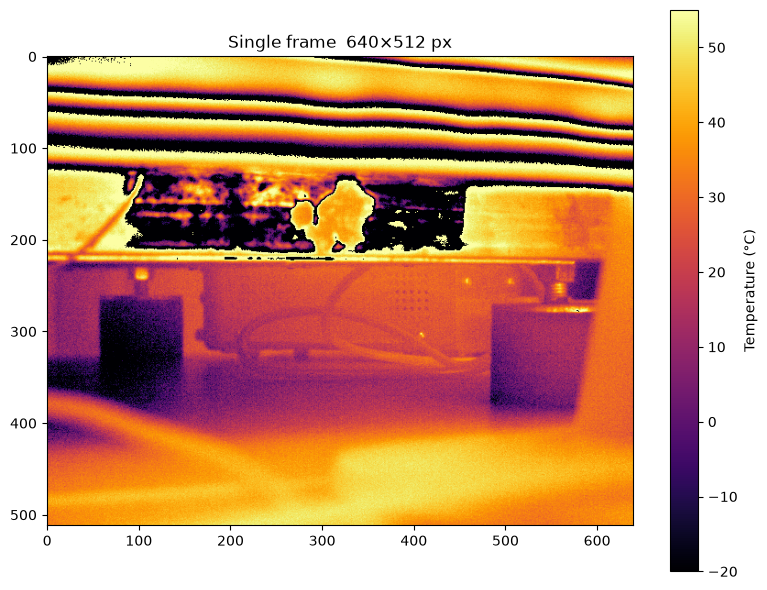

In [30]:
frame = cam.grab()
print(f"Raw frame:  min={frame.min()}, max={frame.max()}, "
      f"mean={frame.mean():.0f}, median={int(np.median(frame))}")

# frame_to_celsius() picks the right path automatically: in TemperatureLinear
# mode it just rescales (camera already did the radiometry); in Radiometric
# mode it applies the calibration polynomial.
disp  = cam.frame_to_celsius(frame)
label = "Temperature (°C)"
print(f"Temperature: min={disp.min():.1f} °C, "
      f"median={np.median(disp):.1f} °C, max={disp.max():.1f} °C")

vmin, vmax = np.percentile(disp, [1, 99])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(disp, cmap='inferno', vmin=vmin, vmax=vmax)
ax.set_title(f'Single frame  {frame.shape[1]}×{frame.shape[0]} px')
plt.colorbar(im, ax=ax, label=label)
plt.tight_layout()
plt.show()


In [12]:
# Compare the two documented radiance->temperature methods on the same frame.
# frame_to_celsius / counts_to_temperature now default to "rbf" (FLIR's official
# formula, KB a_id/3321). The polynomial is a fit and may diverge in the middle
# of the range -- if these disagree a lot, RBF is the one to trust.
f = cam.grab()
t_rbf  = cam.counts_to_temperature(f, method="rbf")
t_poly = cam.counts_to_temperature(f, method="polynomial")
print(f"RBF  (default): median={np.median(t_rbf):.1f}  min={np.nanmin(t_rbf):.1f}  max={np.nanmax(t_rbf):.1f} C")
print(f"polynomial    : median={np.median(t_poly):.1f}  min={np.nanmin(t_poly):.1f}  max={np.nanmax(t_poly):.1f} C")
print(f"max |RBF - poly| difference: {np.nanmax(np.abs(t_rbf - t_poly)):.1f} C")

cal = cam.get_calibration()
print(f"R={cal['r']:.4g}  B={cal['b']:.4g}  F={cal['f']:.4g}")

RBF  (default): median=38.8  min=-20.0  max=55.0 C
polynomial    : median=39.7  min=-20.0  max=55.0 C
max |RBF - poly| difference: 1.8 C
R=6.363  B=3120  F=1


## Live view

Streams continuously and updates the display in-place. Runs for
`LIVE_DURATION` seconds, or stop early with the **■ Stop** button.
Uses `latest=True` so display never lags behind the camera.

In [ ]:
import matplotlib
# Switch to a pop-up window backend; restore inline backend when done
_inline_backend = matplotlib.get_backend()
try:
    plt.switch_backend("TkAgg")
except Exception:
    plt.switch_backend("Qt5Agg")

# --- live view settings ---
LIVE_DURATION  = 30.0   # seconds; close the window or stop the cell to end sooner
TARGET_FPS     = 30.0

cam.start_stream()
frame0  = cam.read(timeout=5.0)
disp0   = cam.frame_to_celsius(frame0)
lv_label = "°C"
vmin, vmax = np.percentile(disp0, [1, 99])

fig, ax = plt.subplots(figsize=(9, 7))
im  = ax.imshow(disp0, cmap="inferno", vmin=vmin, vmax=vmax)
ttl = ax.set_title("Live — frame 1")
plt.colorbar(im, ax=ax, label=lv_label)
plt.tight_layout()
plt.show(block=False)

n, t0 = 1, time.time()
try:
    while time.time() - t0 < LIVE_DURATION:
        t_frame = time.time()
        frame = cam.read(timeout=2.0, latest=True)
        disp  = cam.frame_to_celsius(frame)
        vmin, vmax = np.percentile(disp, [1, 99])
        im.set_data(disp)
        im.set_clim(vmin, vmax)
        n += 1
        elapsed = time.time() - t0
        ttl.set_text(f"Live — frame {n}  ({n / elapsed:.1f} fps)")
        fig.canvas.draw_idle()
        fig.canvas.flush_events()
        wait = 1.0 / TARGET_FPS - (time.time() - t_frame)
        if wait > 0:
            time.sleep(wait)
except KeyboardInterrupt:
    pass
finally:
    cam.stop_stream()
    plt.close(fig)
    plt.switch_backend(_inline_backend)
    print(f"Stopped after {n} frames  ({n / (time.time() - t0):.1f} fps avg).")

## 5. Acquire multiple frames

Streams N frames and returns them as a list of 2-D arrays.
Stack into a 3-D numpy array `(N, H, W)` for analysis.

In [ ]:
frames = cam.acquire(20)
data   = np.stack(frames)            # (N, H, W) uint16
print(f"Acquired: {data.shape}, dtype: {data.dtype}, size: {data.nbytes / 1e6:.1f} MB")

In [ ]:
n, h, w = data.shape
fps      = cam.frame_rate
data_disp = np.stack([cam.frame_to_celsius(f) for f in data])
label    = "Temperature (°C)"
vmin, vmax = np.percentile(data_disp, [1, 99])

indices = np.linspace(0, n - 1, 3, dtype=int)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, indices):
    im = ax.imshow(data_disp[idx], cmap='inferno', vmin=vmin, vmax=vmax)
    ax.set_title(f'Frame {idx}  (t = {idx / fps:.3f} s)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 6. Record a video

Stream at the desired frame rate, capture all frames, and save to an `.npy`
file. The `npy` format preserves the raw uint16 values without any lossy
compression, useful for quantitative analysis.

Playback is shown inline as an animated figure.

In [ ]:
# --- recording settings ---
RECORD_FPS      = 25      # Hz  (must be ≤ frame_rate_max)
RECORD_DURATION = 3.0     # seconds
N_FRAMES        = int(RECORD_FPS * RECORD_DURATION)
OUTPUT_FILE     = "recording.npy"

cam.frame_rate = RECORD_FPS
print(f"Recording {N_FRAMES} frames at {RECORD_FPS} fps  "
      f"({RECORD_DURATION:.1f} s)  …")

video = cam.acquire(N_FRAMES, timeout=RECORD_DURATION + 10.0)
video = np.stack(video)                   # (N, H, W) uint16

np.save(OUTPUT_FILE, video)
print(f"Saved {video.shape}  {video.dtype}  →  {OUTPUT_FILE}  "
      f"({video.nbytes / 1e6:.1f} MB)")

In [ ]:
# Inline playback
video_disp = np.stack([cam.frame_to_celsius(f) for f in video])
label = "°C"
vmin, vmax = np.percentile(video_disp, [1, 99])

fig, ax = plt.subplots(figsize=(7, 5))
im  = ax.imshow(video_disp[0], cmap='inferno', vmin=vmin, vmax=vmax, animated=True)
ttl = ax.set_title('')
plt.colorbar(im, ax=ax, label=label)
plt.tight_layout()

def _update(i):
    im.set_data(video_disp[i])
    ttl.set_text(f'Frame {i}  (t = {i / RECORD_FPS:.3f} s)')
    return im, ttl

ani = animation.FuncAnimation(
    fig, _update, frames=len(video_disp),
    interval=1000 / RECORD_FPS, blit=True
)
plt.close(fig)          # prevent double display
HTML(ani.to_jshtml())

## 7. Visualize

### Temporal statistics

In [ ]:
mean_img = video_disp.mean(axis=0)
std_img  = video_disp.std(axis=0)
units    = "°C" if cal is not None else "counts"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im0 = axes[0].imshow(mean_img, cmap='inferno',
                     vmin=np.percentile(mean_img, 1),
                     vmax=np.percentile(mean_img, 99))
axes[0].set_title('Temporal mean')
plt.colorbar(im0, ax=axes[0], shrink=0.8, label=units)

im1 = axes[1].imshow(std_img, cmap='hot')
axes[1].set_title('Temporal std  (noise / motion map)')
plt.colorbar(im1, ax=axes[1], shrink=0.8, label=units)

plt.tight_layout()
plt.show()

### Pixel time series

In [ ]:
py, px = h // 2, w // 2          # centre pixel
t      = np.arange(len(video_disp)) / RECORD_FPS
units  = "°C" if cal is not None else "Raw counts (uint16)"

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, video_disp[:, py, px], linewidth=0.8)
ax.set_xlabel('Time [s]')
ax.set_ylabel(units)
ax.set_title(f'Centre pixel ({px}, {py})')
ax.set_xlim(0, t[-1])
plt.tight_layout()
plt.show()

## 8. Disconnect

In [ ]:
cam.disconnect()
print("Disconnected.", "streaming:", cam.is_streaming)